In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
df = pd.read_csv("../data/used_car_dataset.csv")

df.head()

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice,car_age
0,Honda,City,2006.5,17.5,98000.0,Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...",195000,19.5
1,Toyota,Innova,2009.0,15.0,150009.5,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...",375000,17.0
2,Volkswagen,VentoTest,2010.0,14.0,77246.0,Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...",184999,16.0
3,Maruti Suzuki,Swift,2017.0,7.0,83500.0,Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,565000,9.0
4,Maruti Suzuki,Baleno,2019.0,5.0,45000.0,Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol",685000,7.0


## Dataset Audit

The dataset is inspected for its shape, data types, missing values, duplicate records, and target-variable distribution before preprocessing.

In [40]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 8851
Number of columns: 12


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9582 entries, 0 to 9581
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Brand         9582 non-null   str  
 1   model         9582 non-null   str  
 2   Year          9582 non-null   int64
 3   Age           9582 non-null   int64
 4   kmDriven      9535 non-null   str  
 5   Transmission  9582 non-null   str  
 6   Owner         9582 non-null   str  
 7   FuelType      9582 non-null   str  
 8   PostedDate    9582 non-null   str  
 9   AdditionInfo  9582 non-null   str  
 10  AskPrice      9582 non-null   str  
dtypes: int64(2), str(9)
memory usage: 823.6 KB


In [5]:
df.describe(include="all")

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
count,9582,9582,9582.000000,9582.000000,9535,9582,9582,9582,9582,9582,9582
unique,39,400,NaN,NaN,1910,2,2,3,12,7307,1330
top,Maruti Suzuki,City,NaN,NaN,"65,000 km",Manual,first,Diesel,Nov-24,"BMW 3 Series GT 320d Luxury Line, 2015, Diesel","₹ 4,50,000"
freq,2720,330,NaN,NaN,198,4800,4800,3840,8693,26,134
mean,NaN,NaN,2016.361094,7.638906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,4.087226,4.087226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1986.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2014.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2017.000000,7.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2019.000000,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing Value Treatment

Missing values in numerical variables are handled using the median because the median is less sensitive to extreme values than the mean. Categorical missing values are handled using the mode, which preserves the most common category.

After treatment, the dataset is checked again to confirm that no missing values remain.

## 1. Missing Value Analysis

We first check for missing values in each feature. Missing values can affect model training and therefore need to be handled before preprocessing and model development.

In [6]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
Brand            0
model            0
Year             0
Age              0
kmDriven        47
Transmission     0
Owner            0
FuelType         0
PostedDate       0
AdditionInfo     0
AskPrice         0
dtype: int64

Total missing values: 47


## 2. Data Type Conversion

The `kmDriven` and `AskPrice` columns contain units, commas, and currency symbols, so they are stored as strings. These non-numeric characters are removed and the columns are converted to numeric values so they can be used for machine learning.

In [7]:
# Convert kmDriven to numeric
df["kmDriven"] = (
    df["kmDriven"]
    .str.replace(",", "", regex=False)
    .str.replace(" km", "", regex=False)
    .str.strip()
)

df["kmDriven"] = pd.to_numeric(df["kmDriven"], errors="coerce")


# Convert AskPrice to numeric
df["AskPrice"] = (
    df["AskPrice"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["AskPrice"] = pd.to_numeric(df["AskPrice"], errors="coerce")


df[["kmDriven", "AskPrice"]].head()

,kmDriven,AskPrice
0,98000.0,195000
1,190000.0,375000
2,77246.0,184999
3,83500.0,565000
4,45000.0,685000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9582 entries, 0 to 9581
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         9582 non-null   str    
 1   model         9582 non-null   str    
 2   Year          9582 non-null   int64  
 3   Age           9582 non-null   int64  
 4   kmDriven      9535 non-null   float64
 5   Transmission  9582 non-null   str    
 6   Owner         9582 non-null   str    
 7   FuelType      9582 non-null   str    
 8   PostedDate    9582 non-null   str    
 9   AdditionInfo  9582 non-null   str    
 10  AskPrice      9582 non-null   int64  
dtypes: float64(1), int64(3), str(7)
memory usage: 823.6 KB


## 3. Handling Missing Values

The missing values in `kmDriven` are numerical. We use the median to fill them because vehicle mileage can contain extreme values, and the median is more robust to outliers than the mean.

In [9]:
median_km = df["kmDriven"].median()

df["kmDriven"] = df["kmDriven"].fillna(median_km)

print("Median kmDriven used:", median_km)
print("Missing kmDriven after imputation:", df["kmDriven"].isnull().sum())

Median kmDriven used: 65000.0
Missing kmDriven after imputation: 0


## 4. Duplicate Records

Duplicate records can cause repeated observations to have an excessive influence on model training. Therefore, we check for and remove exact duplicate rows.

In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 731


In [11]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (8851, 11)


In [12]:
df.describe()

,Year,Age,kmDriven,AskPrice
count,8851.000000,8851.000000,8851.000000,8.851000e+03
mean,2016.377697,7.622303,70979.277370,1.038644e+06
std,4.133730,4.133730,56864.792468,1.650188e+06
min,1986.000000,0.000000,0.000000,1.500000e+04
25%,2014.000000,5.000000,43327.000000,3.500000e+05
50%,2017.000000,7.000000,65000.000000,5.900000e+05
75%,2019.000000,10.000000,86000.000000,1.075000e+06
max,2024.000000,38.000000,980002.000000,4.250000e+07


In [13]:
df.isnull().sum()

Brand           0
model           0
Year            0
Age             0
kmDriven        0
Transmission    0
Owner           0
FuelType        0
PostedDate      0
AdditionInfo    0
AskPrice        0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

## 5. Outlier Detection Using IQR

The Interquartile Range (IQR) method is used to identify potential outliers in numerical variables. A value is considered a potential outlier if it falls below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR.

We examine outliers in `Year`, `Age`, `kmDriven`, and `AskPrice` before deciding how to treat them.

In [15]:
numerical_cols = ["Year", "Age", "kmDriven", "AskPrice"]

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"\n{col}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower bound: {lower_bound}")
    print(f"Upper bound: {upper_bound}")
    print(f"Number of potential outliers: {len(outliers)}")


Year
Q1: 2014.0
Q3: 2019.0
IQR: 5.0
Lower bound: 2006.5
Upper bound: 2026.5
Number of potential outliers: 133

Age
Q1: 5.0
Q3: 10.0
IQR: 5.0
Lower bound: -2.5
Upper bound: 17.5
Number of potential outliers: 133

kmDriven
Q1: 43327.0
Q3: 86000.0
IQR: 42673.0
Lower bound: -20682.5
Upper bound: 150009.5
Number of potential outliers: 338

AskPrice
Q1: 350000.0
Q3: 1075000.0
IQR: 725000.0
Lower bound: -737500.0
Upper bound: 2162500.0
Number of potential outliers: 838


In [16]:
df[numerical_cols].describe()

,Year,Age,kmDriven,AskPrice
count,8851.000000,8851.000000,8851.000000,8.851000e+03
mean,2016.377697,7.622303,70979.277370,1.038644e+06
std,4.133730,4.133730,56864.792468,1.650188e+06
min,1986.000000,0.000000,0.000000,1.500000e+04
25%,2014.000000,5.000000,43327.000000,3.500000e+05
50%,2017.000000,7.000000,65000.000000,5.900000e+05
75%,2019.000000,10.000000,86000.000000,1.075000e+06
max,2024.000000,38.000000,980002.000000,4.250000e+07


## 6. Numerical Feature Boxplots

Boxplots are used to visually inspect the distribution and potential outliers in the numerical features.

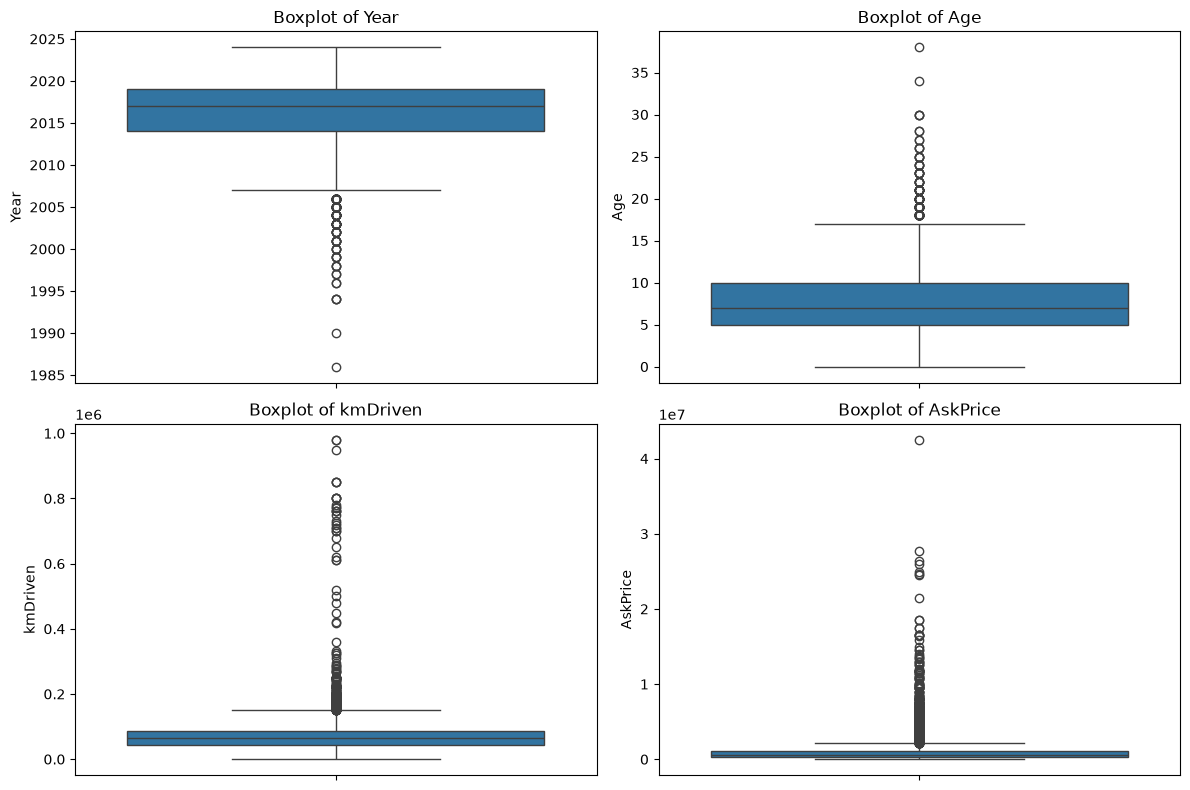

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.ravel(), numerical_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"Boxplot of {col}")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

## 7. Outlier Treatment

The IQR analysis identified potential outliers in the numerical variables. Since extreme values in used-car data can represent legitimate vehicles rather than data-entry errors, we avoid deleting large numbers of observations.

For the numerical predictor variables, IQR-based capping is used to reduce the influence of extreme values while retaining the observations. The target variable `AskPrice` is not capped because it represents the actual prediction target and legitimate high-priced vehicles should remain in the dataset.

In [18]:
# IQR-based capping for numerical predictor variables
# AskPrice is excluded because it is the regression target.

cols_to_cap = ["Year", "Age", "kmDriven"]

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("IQR-based capping applied to:", cols_to_cap)

IQR-based capping applied to: ['Year', 'Age', 'kmDriven']


In [19]:
df[["Year", "Age", "kmDriven", "AskPrice"]].describe()

,Year,Age,kmDriven,AskPrice
count,8851.000000,8851.000000,8851.000000,8.851000e+03
mean,2016.424076,7.575924,67411.801152,1.038644e+06
std,3.981319,3.981319,34929.990325,1.650188e+06
min,2006.500000,0.000000,0.000000,1.500000e+04
25%,2014.000000,5.000000,43327.000000,3.500000e+05
50%,2017.000000,7.000000,65000.000000,5.900000e+05
75%,2019.000000,10.000000,86000.000000,1.075000e+06
max,2024.000000,17.500000,150009.500000,4.250000e+07


## 8. Distribution of Numerical Features

Distribution plots are used to understand the spread, central tendency, and skewness of the numerical variables.

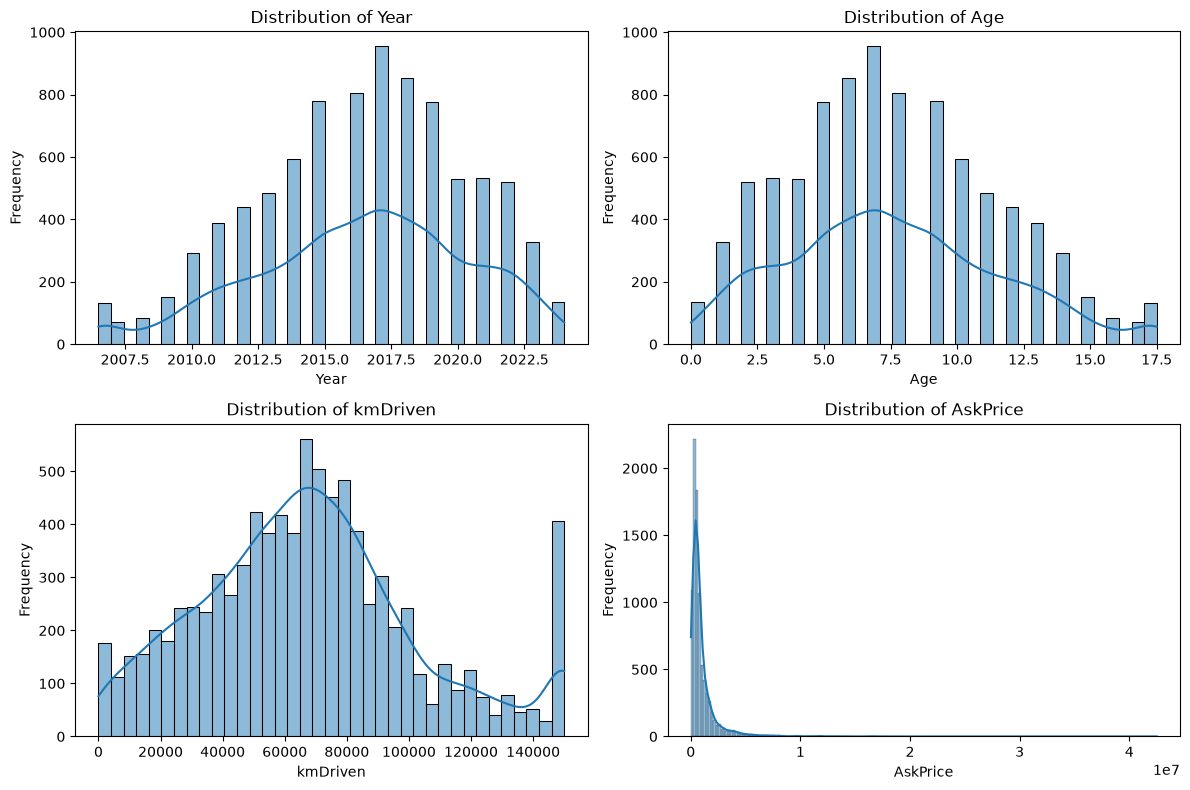

In [20]:
numerical_cols = ["Year", "Age", "kmDriven", "AskPrice"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.ravel(), numerical_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Observation — Year

Most vehicles in the dataset are from relatively recent model years, with fewer observations for older vehicles.

### Observation — Age

The distribution is concentrated around younger and moderately aged vehicles, with fewer older vehicles.

### Observation — kmDriven

The mileage distribution is right-skewed, with most vehicles having moderate mileage and a smaller number of vehicles having substantially higher mileage.

### Observation — AskPrice

The asking price distribution is strongly right-skewed, with most vehicles concentrated at lower prices and a smaller number of high-priced vehicles.

### Categorical Feature Distributions

Count plots are used to examine the distribution of the categorical variables in the dataset. These plots help identify dominant categories and whether some categories have very few observations.

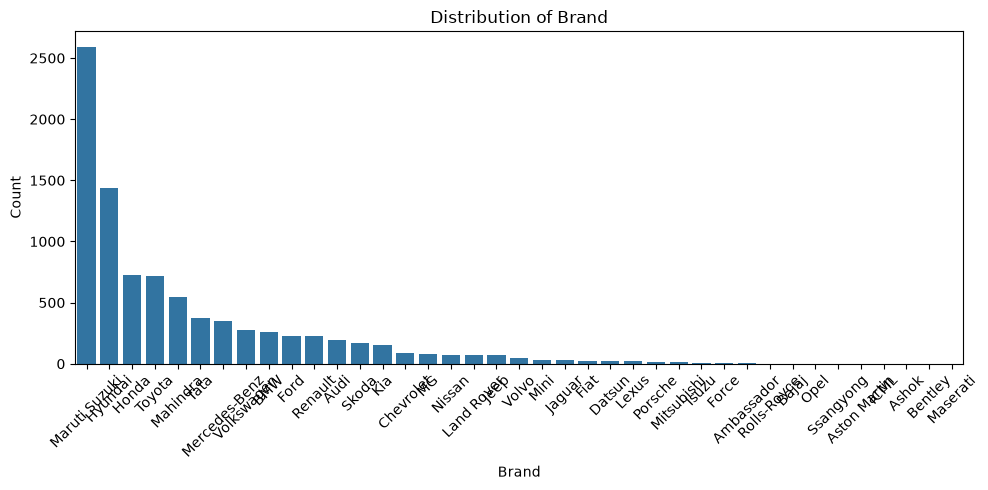

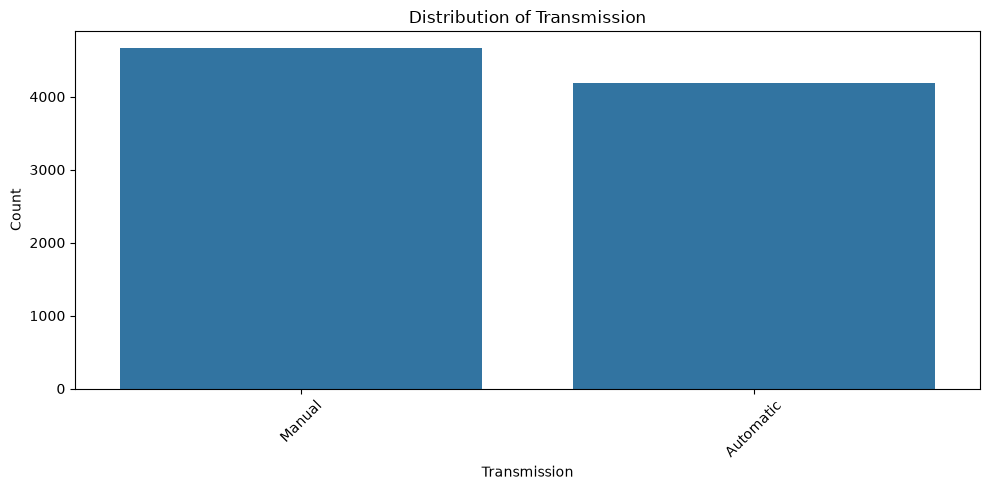

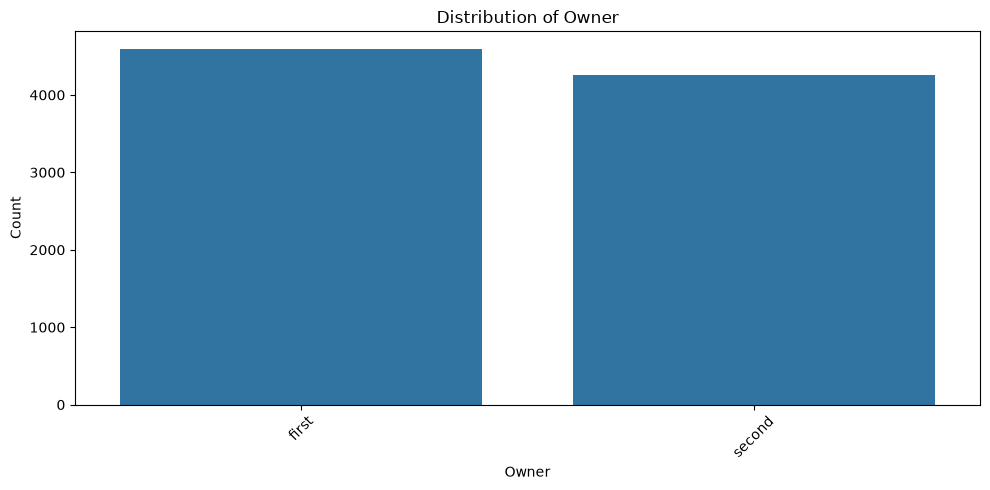

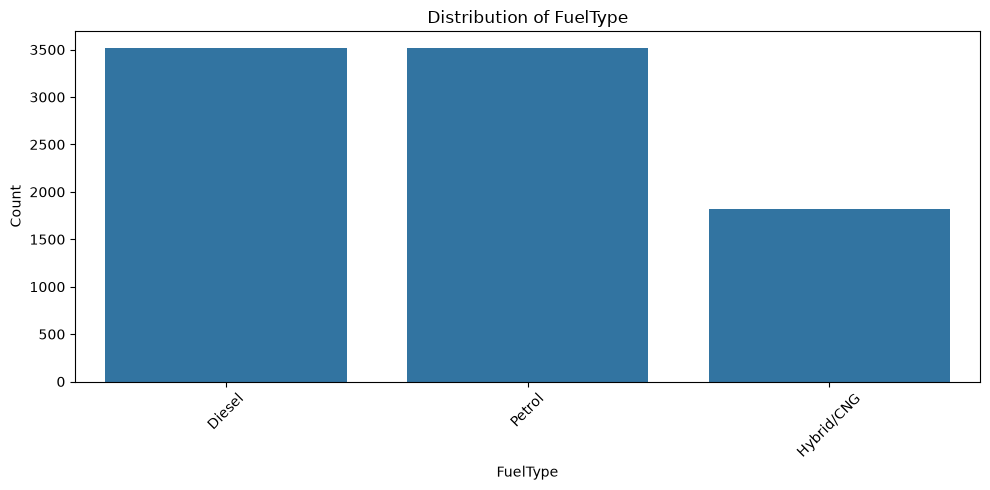

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features = [
    "Brand",
    "Transmission",
    "Owner",
    "FuelType"
]

for col in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Observation — Brand Distribution

The dataset contains vehicles from multiple brands, with some brands appearing much more frequently than others. This indicates an uneven distribution across brands, which should be considered when encoding this categorical feature.

### Observation — Transmission Distribution

The distribution shows the relative frequency of different transmission types. One transmission category is more common than the others, indicating that the dataset is not evenly distributed across transmission types.

### Observation — Owner Distribution

The owner categories are unevenly distributed, with some ownership categories occurring more frequently than others. This feature may provide useful information for predicting used-car prices.

### Observation — Fuel Type Distribution

The dataset contains vehicles using different fuel types, with some fuel categories occurring more frequently than others. Fuel type may contribute to differences in used-car pricing.

## 9. Target Variable Distribution

`AskPrice` is used as the target variable for regression. Its distribution is examined to understand the range and skewness of used-car prices.

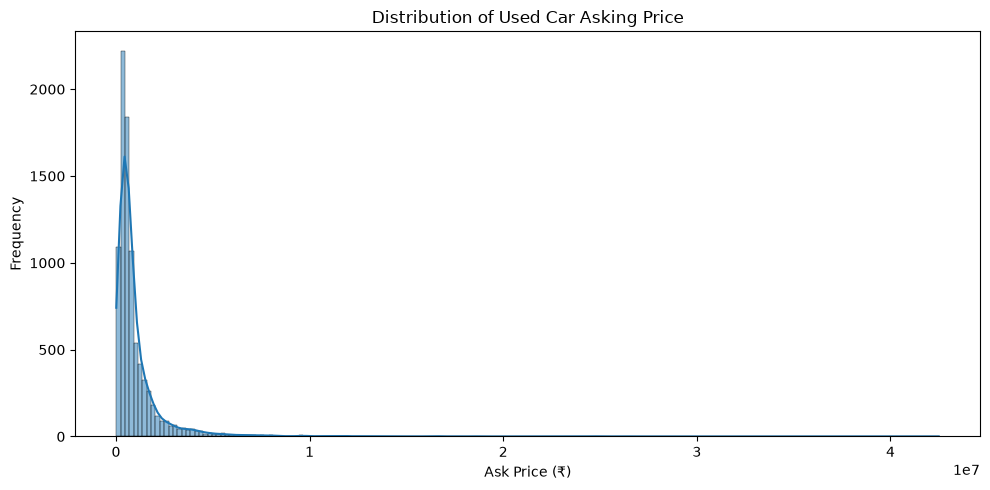

In [21]:
plt.figure(figsize=(10, 5))

sns.histplot(df["AskPrice"], kde=True)

plt.title("Distribution of Used Car Asking Price")
plt.xlabel("Ask Price (₹)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Observation

The asking price distribution is highly right-skewed, indicating that most vehicles have relatively lower asking prices while a smaller number of vehicles have substantially higher prices.

## 10. Correlation Analysis

A correlation heatmap is used to examine the relationships between numerical variables. This helps identify features that may have a strong relationship with the target variable, `AskPrice`.

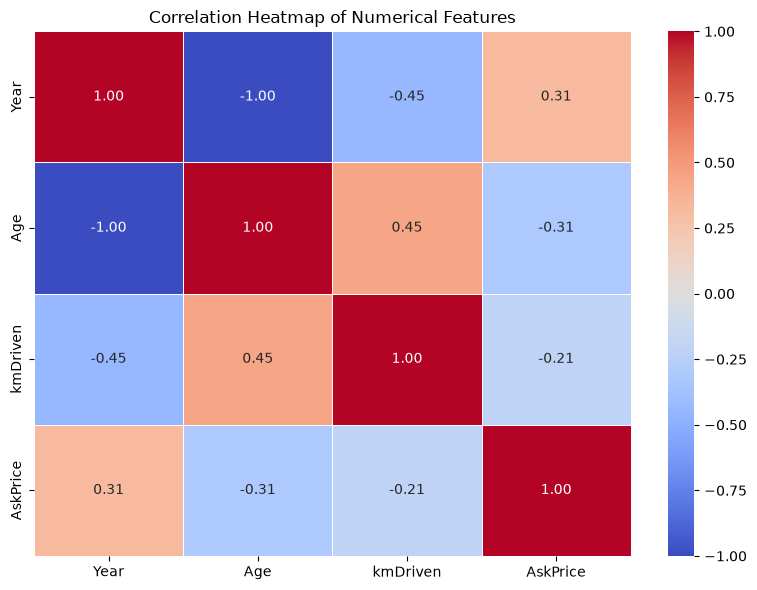

In [22]:
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

### Observation

Year and Age show a perfect negative correlation (-1.00), indicating that they contain essentially the same age-related information. Year has a positive correlation with AskPrice (0.31), while Age has a negative correlation (-0.31). kmDriven has a weak negative correlation with AskPrice (-0.21).

## 11. Feature vs Asking Price Analysis

Scatter plots are used to visually examine the relationship between individual numerical features and the target variable, `AskPrice`.

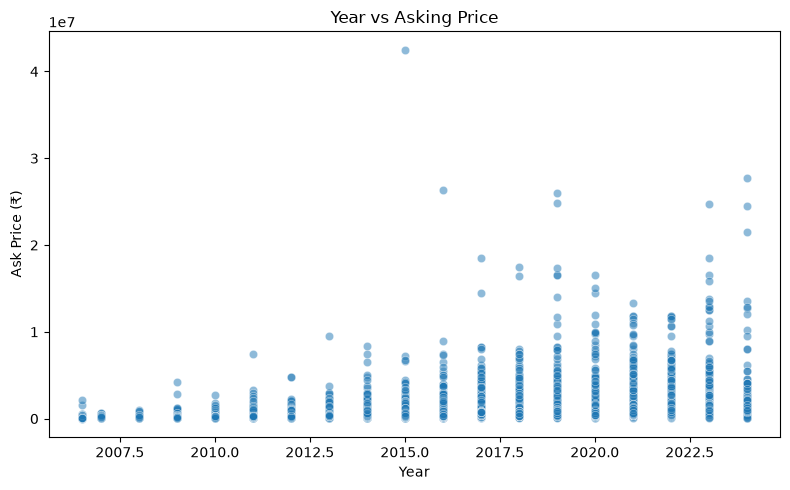

In [23]:
# Year vs AskPrice
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Year", y="AskPrice", alpha=0.5)

plt.title("Year vs Asking Price")
plt.xlabel("Year")
plt.ylabel("Ask Price (₹)")
plt.tight_layout()
plt.show()

### Observation — Year vs Asking Price

The scatter plot shows a general tendency for newer vehicles to have higher asking prices, although there is considerable variation in prices within individual model years.

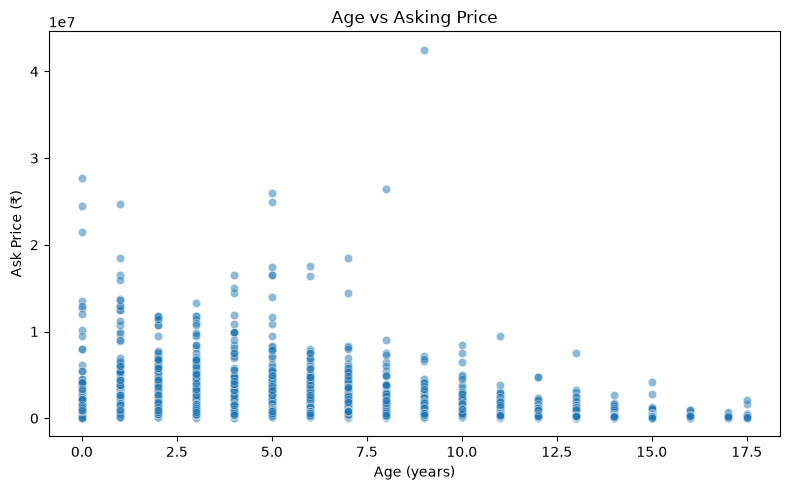

In [24]:
# Age vs AskPrice
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Age", y="AskPrice", alpha=0.5)

plt.title("Age vs Asking Price")
plt.xlabel("Age (years)")
plt.ylabel("Ask Price (₹)")
plt.tight_layout()
plt.show()

### Observation — Age vs Asking Price

The plot shows a general tendency for asking prices to decrease as vehicle age increases, although other factors also contribute to price variation.

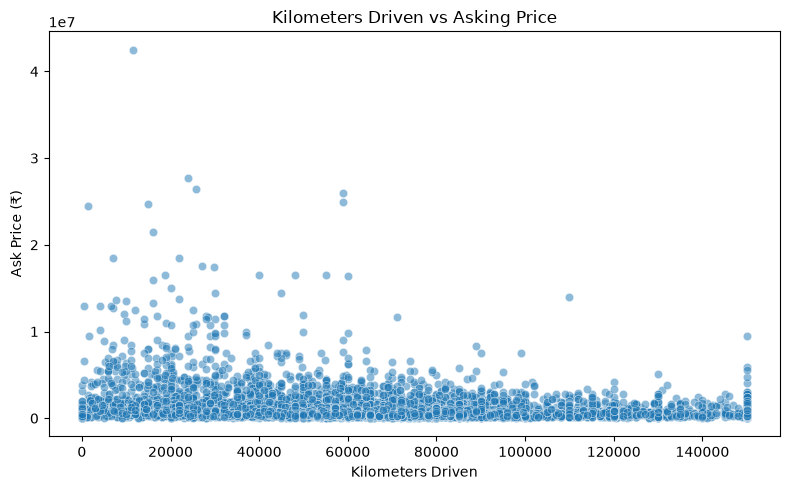

In [25]:
# kmDriven vs AskPrice
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="kmDriven", y="AskPrice", alpha=0.5)

plt.title("Kilometers Driven vs Asking Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Ask Price (₹)")
plt.tight_layout()
plt.show()

### Observation — kmDriven vs Asking Price

The plot shows a weak negative relationship between kilometers driven and asking price, with higher-mileage vehicles generally tending to have lower asking prices.

## 12. Feature Engineering — Car Age

A new feature, `car_age`, is created from the vehicle's manufacturing year. Car age is directly relevant to used-car pricing because older vehicles generally depreciate over time.

The current year, 2026, is used as the reference year so that the feature represents the approximate current age of each vehicle.

In [26]:
df["car_age"] = 2026 - df["Year"]

df[["Year", "car_age"]].head()

,Year,car_age
0,2006.5,19.5
1,2009.0,17.0
2,2010.0,16.0
3,2017.0,9.0
4,2019.0,7.0


In [27]:
df[["Year", "Age", "car_age"]].head(10)

,Year,Age,car_age
0,2006.5,17.5,19.5
1,2009.0,15.0,17.0
2,2010.0,14.0,16.0
3,2017.0,7.0,9.0
4,2019.0,5.0,7.0
5,2014.0,10.0,12.0
6,2014.0,10.0,12.0
7,2019.0,5.0,7.0
8,2020.0,4.0,6.0
9,2017.0,7.0,9.0


## 13. Feature and Target Selection

`AskPrice` is selected as the regression target. The explanatory features include vehicle characteristics such as brand, model, mileage, transmission, ownership history, fuel type, and engineered car age.

Redundant and unsuitable raw fields are excluded from the initial model.

In [28]:
features = [
    "Brand",
    "model",
    "kmDriven",
    "Transmission",
    "Owner",
    "FuelType",
    "car_age"
]

X = df[features].copy()
y = df["AskPrice"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8851, 7)
y shape: (8851,)


## 14. Train-Test Split

The dataset is divided into training and testing sets using an 80:20 split. Since `AskPrice` is a continuous regression target, direct stratification on the exact target values is unsuitable. Therefore, price ranges are temporarily created for stratification to maintain a similar distribution of prices in both sets.

The original continuous `AskPrice` values remain unchanged for regression.

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
# Create temporary price bins for stratification
price_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=price_bins
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7080, 7)
X_test: (1771, 7)
y_train: (7080,)
y_test: (1771,)


### Train-Test results

The dataset is divided into 80% training data and 20% testing data. Since `AskPrice` is a continuous regression target, quantile-based price bins are temporarily created for stratification. This helps maintain a similar distribution of target prices in both training and testing sets.

## 15. Encoding and Feature Scaling

Categorical variables are converted into numerical form using one-hot encoding. Numerical features are standardized using `StandardScaler`.

To prevent data leakage, the preprocessing transformations are fitted only on the training data and then applied to both the training and testing sets.

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [32]:
categorical_features = [
    "Brand",
    "model",
    "Transmission",
    "Owner",
    "FuelType"
]

numerical_features = [
    "kmDriven",
    "car_age"
]

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [34]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (7080, 432)
Processed X_test shape: (1771, 432)


7,080 training cars
1,771 test cars
432 processed features after one-hot encoding + scaling.

In [35]:
# Use the processed data for machine learning models
X_train = X_train_processed
X_test = X_test_processed

print("Final X_train shape:", X_train.shape)
print("Final X_test shape:", X_test.shape)

Final X_train shape: (7080, 432)
Final X_test shape: (1771, 432)


In [36]:
import joblib

joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("Preprocessor saved successfully!")

Preprocessor saved successfully!


In [37]:
df.to_csv("../data/used_car_dataset.csv", index=False)
print("Cleaned dataset saved successfully!")
print("Final shape:", df.shape)

Cleaned dataset saved successfully!
Final shape: (8851, 12)
